In [7]:
%cd "./MielPops/"

/content/MielPops


In [18]:
import pandas as pd
import numpy as np
import csv
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
# import torchinfo
import torchvision
from tqdm import tqdm

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import v2

from model.loader import load_dataset, load_test_loader
from utils.CustomDataset import CustomDataset
from utils.CustomSkibidiDataset import CustomSkibidiDataset

import torchvision.models as models
from eval.Analyser import Analyser, plot_f1_report
from result.repondeur import prediction_val_to_csv

In [19]:
# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("⚠ Using CPU - training will be slow!")

✓ Using GPU: Tesla T4


In [20]:
def train_crossEntropyLoss(train_set, val_set, model, epochs):
    """
    Entraine un model à partir d'un train_set donné. Retourne les metrics de l'entrainement
    """

    # Parameters
    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

    # optimizer = torch.optim.SGD(
    #     model.parameters(),
    #     lr=0.1,
    #     momentum=0.9,
    #     weight_decay=5e-4
    # )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=200
    )


    accuracies = np.zeros(epochs)
    losses = np.zeros(epochs)
    f1scores = np.zeros(epochs)

    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(
            train_set,
            desc=f"Model training | Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            #prediction
            logits = model(images)
            loss = criterion(logits, labels)

            #propagation du gradient
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calcul des metriques
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({
                "batch_loss": f"{loss.item():.4f}",
                "accuracy": f"{correct/total*100:.2f}%"
            })
        accuracies[epoch] = correct/total
        losses[epoch] = total_loss

        scheduler.step()

        model_epoch_path =  f"model/trained_model/ResNet_augmented_data_{epoch + 1}_epochs.pth"
        torch.save(model.state_dict(), model_epoch_path)

        # Validation
        model.eval()
        val_csv_path = f"model/trained_model/prediction_validation_{epoch + 1}_epochs.csv"
        prediction_val_to_csv(dataset=val_set, model=model, output_path=val_csv_path)

        analyser = Analyser(pd.read_csv(val_csv_path))
        report = analyser.generate_report()
        print(report)
        f1scores[epoch]=report['f1_score_avg']

        # Back to training
        model.train()
    return accuracies, losses, f1scores

In [21]:
# 1. Define Image Transforms
# HUUUUGOOOOOOOO
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     torchvision.transforms.functional.to_dtype(float16, scale=True),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

transform = v2.Compose([
    #v2.ToImage(),                  # Convert to Tensor (if it's PIL)
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True), # Scales to float16 [0, 1] # TODO
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 2. Instantiate your Dataset
"""train_dataset = CustomDataset(
    img_dir='data/',
    annotations_file='data/train.csv',
    transform=transform,
    target_transform=None # ???
)"""

skibidi_dataset = CustomSkibidiDataset(
    img_dir='data/treated_train/',
    csv_mapper='data/treated_train.csv',
    transform=transform,
    target_transform=None # ???
)

train_size = int(0.8 * len(skibidi_dataset))
test_size = len(skibidi_dataset) - train_size

train_dataset, validation_dataset = random_split(skibidi_dataset, [train_size, test_size])

Found folders ['Andrena ventralis', 'Andrena plana', 'Andrena vicinoides', 'Andrena mediovittata', 'Andrena wilkella', 'Andrena cineraria', 'Andrena orbitalis', 'Andrena vaga', 'Andrena rudbeckiae', 'Andrena carantonica', 'Andrena chengtehensis', 'Andrena melanochroa', 'Andrena hattorfiana', 'Andrena banksi', 'Andrena hesperia', 'Andrena barbilabris', 'Andrena aliciae', 'Andrena fulvata', 'Andrena haemorrhoa', 'Andrena rufula', 'Andrena crawfordi', 'Andrena lineolata', 'Andrena irana', 'Andrena fulva', 'Andrena angustitarsata', 'Andrena dilleri', 'Andrena aerinifrons', 'Andrena discors', 'Andrena flavipes', 'Andrena villipes', 'Andrena denticulata', 'Andrena afrensis', 'Andrena fortipunctata', 'Andrena limbata', 'Andrena pinguis', 'Andrena clarkella', 'Andrena costillensis', 'Andrena convallaria', 'Andrena dorsata', 'Andrena leucophaea', 'Andrena barbareae', 'Andrena florivaga', 'Andrena nitida', 'Andrena bicolor', 'Andrena mendica', 'Andrena vulpecula', 'Andrena perimelas', 'Andrena n

In [22]:
if not(os.path.exists("model/trained_model/")):
    os.makedirs("model/trained_model/")

epochs = 30
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
num_classes = 50
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.to(device)

train_set = DataLoader(
    dataset=train_dataset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle every epoch to prevent overfitting
    num_workers=4,      # Number of CPU cores for data loading
    pin_memory=True     # Speeds up transfer to GPU
)

val_set = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the wo

In [23]:
accuracies, losses, f1scores = train_crossEntropyLoss(train_set, val_set, model, epochs)

try :
    np.save("./ACCURACIES.npy", accuracies)
    np.save("./LOSSES.npy", losses)
    np.save("./F1SCORES.npy", f1scores)
except :
    pass
torch.save(model.state_dict(), f"model/trained_model/ResNet_augmented_data_{epochs}_epochs.pth")

Model training | Epoch 1/30:   0%|          | 0/779 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Model training | Epoch 1/30: 100%|██████████| 779/779 [01:20<00:00,  9.68it/s, batch_loss=1.1406, accuracy=59.18%]


✓ Using GPU: Tesla T4


Inference: 100%|██████████| 195/195 [00:20<00:00,  9.35it/s]


Les predictions ont été sauvegardees dans model/trained_model/prediction_validation_1_epochs.csv.
{'f1_score_avg': 0.7183534746161536, 'f1_score_per_class': array([0.98901099, 0.22900763, 0.92631579, 0.82285714, 0.46715328,
       0.75268817, 0.92028986, 0.96703297, 0.64485981, 0.95205479,
       0.78947368, 0.04878049, 0.90196078, 0.57647059, 0.7281106 ,
       0.7079646 , 0.4556962 , 0.44137931, 0.69076305, 0.98461538,
       0.72519084, 0.65      , 0.72      , 0.41403509, 0.65653495,
       0.80745342, 0.42396313, 0.81481481, 0.96296296, 0.97416974,
       0.20359281, 0.87227414, 0.98916968, 0.86930091, 0.42222222,
       0.8683274 , 0.70080863, 0.77675841, 0.5959596 , 0.32941176,
       0.77160494, 0.42524917, 0.78417266, 0.60294118, 0.91333333,
       0.81481481, 0.68619247]), 'best_f1': np.int64(32)}


Model training | Epoch 2/30:   0%|          | 0/779 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Model training | Epoch 2/30: 100%|██████████| 779/779 [01:22<00:00,  9.45it/s, batch_loss=0.7430, accuracy=74.64%]


...

Les predictions ont été sauvegardees dans model/trained_model/prediction_validation_29_epochs.csv.
{'f1_score_avg': 0.8251492867042578, 'f1_score_per_class': array([1.        , 0.45      , 0.97491039, 0.96393443, 0.57711443,
       0.89156627, 0.97777778, 0.99622642, 0.9023569 , 1.        ,
       0.90551181, 0.38518519, 0.96268657, 0.8018018 , 0.904     ,
       0.82392027, 0.52631579, 0.60674157, 0.79452055, 0.99076923,
       0.92753623, 0.55948553, 0.83174603, 0.42352941, 0.7080292 ,
       0.97122302, 0.49494949, 0.97264438, 0.99661017, 0.99242424,
       0.42342342, 0.98780488, 1.        , 0.96949153, 0.45245902,
       0.96376812, 0.98916968, 0.89836066, 0.54143646, 0.50641026,
       0.91694352, 0.4973545 , 0.96503497, 0.83516484, 0.98136646,
       0.89632107, 0.68148148]), 'best_f1': np.int64(0)}


Model training | Epoch 30/30:   0%|          | 0/779 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Model training | Epoch 30/30: 100%|██████████| 779/779 [01:24<00:00,  9.25it/s, batch_loss=0.4790, accuracy=89.91%]


✓ Using GPU: Tesla T4


Inference: 100%|██████████| 195/195 [00:21<00:00,  9.13it/s]


Les predictions ont été sauvegardees dans model/trained_model/prediction_validation_30_epochs.csv.
{'f1_score_avg': 0.8196181152067639, 'f1_score_per_class': array([1.        , 0.42727273, 0.96478873, 0.87463557, 0.58479532,
       0.93333333, 0.96703297, 0.9924812 , 0.91489362, 0.99651568,
       0.94514768, 0.25641026, 0.96268657, 0.77824268, 0.91764706,
       0.92537313, 0.59907834, 0.56962025, 0.78321678, 0.98773006,
       0.88815789, 0.57894737, 0.83687943, 0.50684932, 0.57004831,
       0.96167247, 0.45398773, 0.96716418, 1.        , 0.98876404,
       0.25925926, 0.98148148, 1.        , 0.96949153, 0.46376812,
       0.97777778, 0.94276094, 0.9       , 0.66367713, 0.51973684,
       0.88732394, 0.48351648, 0.96819788, 0.79881657, 0.98742138,
       0.90657439, 0.7109375 ]), 'best_f1': np.int64(0)}


#### Analysis of model training

In [8]:
# --- Load arrays ---
accuracies = np.load("./ACCURACIES.npy")
losses = np.load("./LOSSES.npy")
f1scores = np.load("./F1SCORES.npy")

# --- Create epoch axis ---
epochs = np.arange(len(accuracies))

# --- Create subplots (3 rows, shared x-axis) ---
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=("Accuracy", "Loss", "F1 Score")
)

# --- Accuracy subplot ---
fig.add_trace(
    go.Scatter(x=epochs, y=accuracies,
               mode="lines+markers",
               name="Accuracy"),
    row=1, col=1
)

# --- Loss subplot ---
fig.add_trace(
    go.Scatter(x=epochs, y=losses,
               mode="lines+markers",
               name="Loss"),
    row=2, col=1
)

# --- F1 subplot ---
fig.add_trace(
    go.Scatter(x=epochs, y=f1scores,
               mode="lines+markers",
               name="F1 Score"),
    row=3, col=1
)

# --- Layout ---
fig.update_layout(
    height=800,
    title="Training Metrics per Epoch",
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(title_text="Epoch", row=3, col=1)

fig.show()

Last epoch

In [26]:
analyser = Analyser(pd.read_csv(f"model/trained_model/prediction_validation_30_epochs.csv"))
report = analyser.generate_report()
print(report)

{'f1_score_avg': 0.8196181152067639, 'f1_score_per_class': array([1.        , 0.42727273, 0.96478873, 0.87463557, 0.58479532,
       0.93333333, 0.96703297, 0.9924812 , 0.91489362, 0.99651568,
       0.94514768, 0.25641026, 0.96268657, 0.77824268, 0.91764706,
       0.92537313, 0.59907834, 0.56962025, 0.78321678, 0.98773006,
       0.88815789, 0.57894737, 0.83687943, 0.50684932, 0.57004831,
       0.96167247, 0.45398773, 0.96716418, 1.        , 0.98876404,
       0.25925926, 0.98148148, 1.        , 0.96949153, 0.46376812,
       0.97777778, 0.94276094, 0.9       , 0.66367713, 0.51973684,
       0.88732394, 0.48351648, 0.96819788, 0.79881657, 0.98742138,
       0.90657439, 0.7109375 ]), 'best_f1': np.int64(0)}


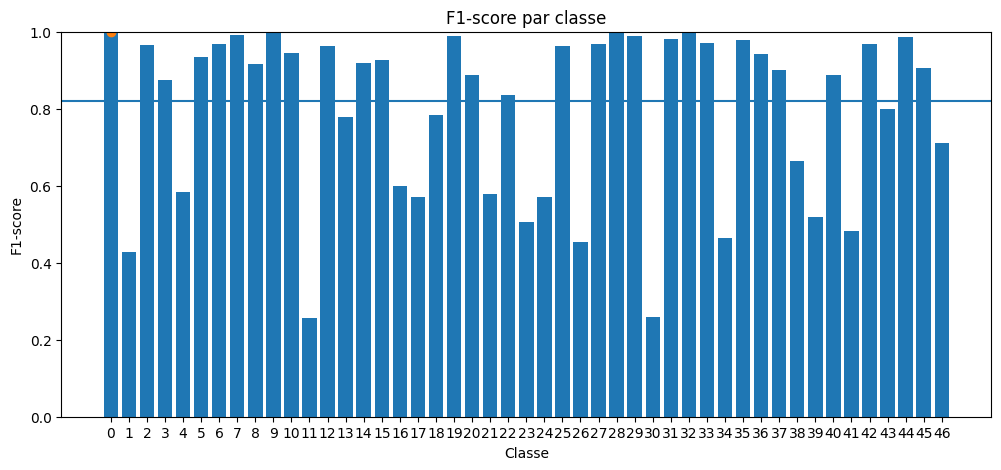

In [27]:
plot_f1_report(report)